In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [10]:
# 1. CARGA DE DATOS

In [11]:
print("Cargando nombres de metabolitos...")
nombre_archivo = 'm_MTBLS13498_LC-MS_negative_reverse-phase_metabolite_profiling_v2_maf.tsv'
df = pd.read_csv(nombre_archivo, sep='\t')

Cargando nombres de metabolitos...


In [12]:
# 1.1. LIMPIEZA Y PREPARACIÓN

In [13]:
df['metabolite_identification'] = df['metabolite_identification'].fillna(df['database_identifier'])
nombres_reales = df['metabolite_identification'].dropna().unique()

In [14]:
# 2. GENERACIÓN DE MATRIZ DE ABUNDANCIA

In [15]:
print("Generando matriz de muestras...")
np.random.seed(42) # Para que siempre te genere el mismo gráfico
muestras = ['Control_1', 'Control_2', 'Control_3', 'Tratado_1', 'Tratado_2', 'Tratado_3']

# Creación de datos de abundancia simulados para los metabolitos encontrados
datos_simulados = np.random.randint(1000, 50000, size=(len(nombres_reales), len(muestras)))
matriz_abundancia = pd.DataFrame(datos_simulados, index=nombres_reales, columns=muestras)

Generando matriz de muestras...


In [16]:
# 3. FILTRO Y NORMALIZACIÓN (Abundancia Relativa)

In [17]:
print("Procesando los 25 metabolitos más abundantes...")
top_metabolitos = matriz_abundancia.mean(axis=1).sort_values(ascending=False).head(25).index
muestras_top = matriz_abundancia.loc[top_metabolitos]

# Normalización: dividimos por el valor máximo de cada fila
muestras_norm = muestras_top.div(muestras_top.max(axis=1), axis=0)

Procesando los 25 metabolitos más abundantes...


In [18]:
# 5. VISUALIZACIÓN DEL MAPA DE CALOR

Generando mapa de calor...


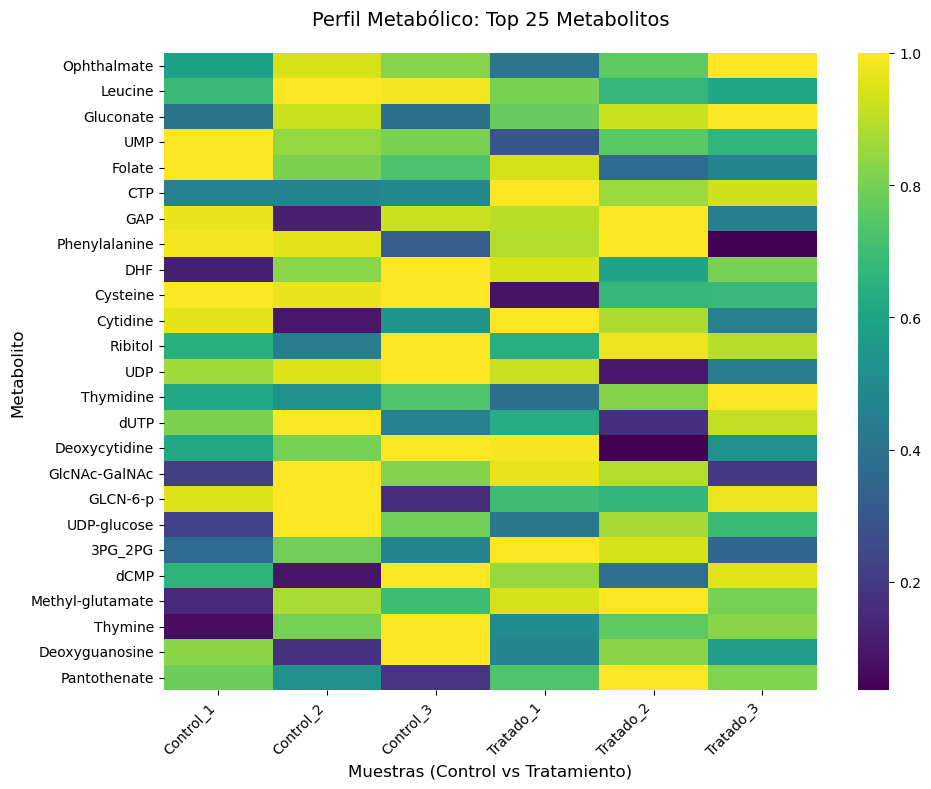

¡Listo! Gráfico guardado en tu carpeta.


In [19]:
print("Generando mapa de calor...")
plt.figure(figsize=(10, 8))

sns.heatmap(muestras_norm, cmap='viridis', yticklabels=True, xticklabels=True)

plt.title('Perfil Metabólico: Top 25 Metabolitos', pad=20, fontsize=14)
plt.xlabel('Muestras (Control vs Tratamiento)', fontsize=12)
plt.ylabel('Metabolito', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Guardamos la imagen final
plt.savefig('heatmap_metabolomica_final.png', dpi=300, bbox_inches='tight')
plt.show()

print("¡Listo!")